# GSM State Function 2 - Lightweight Implementation

This notebook demonstrates the `GSMStateFn2` class, a simplified approach to thermodynamic state function representation using symbolic variables organized into natural and conjugate categories.

## Key Features:
- Lightweight design with minimal complexity
- Clear separation of natural vs conjugate variables
- Thermal, mechanical, and internal variable domains
- Simple interface for constitutive relation computation

## Import Required Libraries

Import sympy for symbolic mathematics, typing for type hints, and other necessary modules.

In [1]:
import sympy as sp
from typing import Optional
import sys
import os

# Add the current directory to Python path for importing our module
sys.path.insert(0, os.getcwd())

# Import our lightweight state function class
from gsm_state_fn2 import GSMStateFn2

# Enable LaTeX rendering for better display
sp.init_printing(use_latex=True)

## Define Symbolic Variables

Create symbolic variables for our thermodynamic state function demonstration.

In [ ]:
# Define thermal variables
T = sp.Symbol('T', real=True, positive=True)  # Temperature (intensive)
S = sp.Symbol('S', real=True)                 # Entropy (extensive)

# Define mechanical variables  
eps = sp.Symbol('epsilon', real=True)             # Strain (extensive)
sig = sp.Symbol('sigma', real=True)             # Stress (intensive)

# Define material parameters
E = sp.Symbol('E', real=True, positive=True)  # Young's modulus
omega = sp.Symbol('omega', real=True)         # Damage parameter
Y = sp.Symbol('Y', real=True)                 # Internal stress (intensive)

print("Symbolic variables defined:")
print(f"Thermal: T={T}, S={S}")
print(f"Mechanical: eps={eps}, sig={sig}")
print(f"Parameters: E={E}, omega={omega}")

Symbolic variables defined:
Thermal: T=T, S=S
Mechanical: eps=epsilon, sig=sigma
Internal: Eps=Eps, Sig=Sig
Parameters: E=E, omega=omega


## Create Class Instance with Example Function

Instantiate the GSMStateFn2 class with a simple thermodynamic function expression - a Helmholtz free energy for a damaged elastic material.

In [ ]:
# Define a Helmholtz free energy expression: F(T, ε, Ɛ)
# Simple damaged elastic energy with temperature dependence
F_expr = sp.Rational(1,2) * (1 - omega) * E * eps**2 + sp.Rational(1,2) * Eps**2

print("Helmholtz Free Energy Expression:")
sp.pprint(F_expr)
print()

# Create GSMStateFn2 instance for Helmholtz free energy F(T, ε, Ɛ)
# Natural variables: T (thermal), eps (mechanical), Eps (internal)
# Conjugate variables: S (thermal), sig (mechanical), Sig (internal)
helmholtz_fn = GSMStateFn2(
    fn_expr=F_expr,
    th_x_var=T,      # Temperature is natural for Helmholtz
    th_y_var=S,      # Entropy is conjugate (S = -∂F/∂T)
    mc_x_var=eps,    # Strain is natural for Helmholtz
    mc_y_var=sig,    # Stress is conjugate (σ = ∂F/∂ε)
    Eps_var=(omega,)     # Internal strain is natural
    Sig_var=(Y,)      # Internal stress is conjugate (𝒮 = ∂F/∂Ɛ)
)

print("GSMStateFn2 instance created successfully!")
print(helmholtz_fn)

Helmholtz Free Energy Expression:
                    2
     2 ⎛1   ω⎞   Eps 
E⋅eps ⋅⎜─ - ─⎟ + ────
       ⎝2   2⎠    2  

GSMStateFn2 instance created successfully!
GSMStateFn2(f(T, eps, Eps) = E*eps**2*(1/2 - omega/2) + Eps**2/2)
                    2
     2 ⎛1   ω⎞   Eps 
E⋅eps ⋅⎜─ - ─⎟ + ────
       ⎝2   2⎠    2  

GSMStateFn2 instance created successfully!
GSMStateFn2(f(T, eps, Eps) = E*eps**2*(1/2 - omega/2) + Eps**2/2)


## Display Function Expression

Render and display the mathematical expression of the thermodynamic function using sympy's display capabilities.

State Function Overview:
GSM State Function Overview
Expression: E*eps**2*(1/2 - omega/2) + Eps**2/2

Natural Variables (independent):
  Thermal: T
  Mechanical: eps
  Internal: Eps

Conjugate Variables (derivatives):
  Thermal: S
  Mechanical: sig
  Internal: Sig


Mathematical Expression (LaTeX rendering):


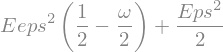


Function signature: F(T, eps, Eps)


In [4]:
print("State Function Overview:")
helmholtz_fn.print_overview()

print("\nMathematical Expression (LaTeX rendering):")
display(helmholtz_fn.fn_expr)

print(f"\nFunction signature: F({', '.join(str(var) for var in helmholtz_fn.get_natural_variables())})")

## Review Available Variables

List and display all available thermodynamic variables (both natural and conjugate) with their symbolic representations.

In [5]:
print("Variable Organization:")
print("=" * 40)

print("\nNatural Variables (independent):")
natural_vars = helmholtz_fn.get_natural_variables()
for i, var in enumerate(natural_vars, 1):
    print(f"  {i}. {var}")

print("\nConjugate Variables (derivatives):")
conjugate_vars = helmholtz_fn.get_conjugate_variables()
for i, var in enumerate(conjugate_vars, 1):
    print(f"  {i}. {var}")

print(f"\nTotal variables: {len(helmholtz_fn.get_all_variables())}")

print("\nVariable Details:")
print(f"  Thermal natural: {helmholtz_fn.th_x_var}")
print(f"  Thermal conjugate: {helmholtz_fn.th_y_var}")
print(f"  Mechanical natural: {helmholtz_fn.mc_x_var}")
print(f"  Mechanical conjugate: {helmholtz_fn.mc_y_var}")
print(f"  Internal natural: {helmholtz_fn.Eps_var}")
print(f"  Internal conjugate: {helmholtz_fn.Sig_var}")

Variable Organization:

Natural Variables (independent):
  1. T
  2. eps
  3. Eps

Conjugate Variables (derivatives):
  1. S
  2. sig
  3. Sig

Total variables: 6

Variable Details:
  Thermal natural: T
  Thermal conjugate: S
  Mechanical natural: eps
  Mechanical conjugate: sig
  Internal natural: Eps
  Internal conjugate: Sig


## Test Variable Access

Demonstrate accessing individual variables from the class instance and verify their properties and types.

In [6]:
print("Variable Access Testing:")
print("=" * 30)

# Test individual variable access
print("Thermal Variables:")
print(f"  Natural (th_x_var): {helmholtz_fn.th_x_var} (type: {type(helmholtz_fn.th_x_var)})")
print(f"  Conjugate (th_y_var): {helmholtz_fn.th_y_var} (type: {type(helmholtz_fn.th_y_var)})")

print("\nMechanical Variables:")
print(f"  Natural (mc_x_var): {helmholtz_fn.mc_x_var} (type: {type(helmholtz_fn.mc_x_var)})")
print(f"  Conjugate (mc_y_var): {helmholtz_fn.mc_y_var} (type: {type(helmholtz_fn.mc_y_var)})")

print("\nInternal Variables:")
print(f"  Natural (Eps_var): {helmholtz_fn.Eps_var} (type: {type(helmholtz_fn.Eps_var)})")
print(f"  Conjugate (Sig_var): {helmholtz_fn.Sig_var} (type: {type(helmholtz_fn.Sig_var)})")

# Verify variables are sympy symbols
print(f"\nVerification - All variables are sympy.Symbol:")
all_vars = helmholtz_fn.get_all_variables()
for var in all_vars:
    print(f"  {var}: {isinstance(var, sp.Symbol)}")

Variable Access Testing:
Thermal Variables:
  Natural (th_x_var): T (type: <class 'sympy.core.symbol.Symbol'>)
  Conjugate (th_y_var): S (type: <class 'sympy.core.symbol.Symbol'>)

Mechanical Variables:
  Natural (mc_x_var): eps (type: <class 'sympy.core.symbol.Symbol'>)
  Conjugate (mc_y_var): sig (type: <class 'sympy.core.symbol.Symbol'>)

Internal Variables:
  Natural (Eps_var): Eps (type: <class 'sympy.core.symbol.Symbol'>)
  Conjugate (Sig_var): Sig (type: <class 'sympy.core.symbol.Symbol'>)

Verification - All variables are sympy.Symbol:
  T: True
  eps: True
  Eps: True
  S: True
  sig: True
  Sig: True


## Compute Constitutive Relations

Demonstrate the computation of constitutive relations through partial derivatives.

In [7]:
print("Constitutive Relations:")
helmholtz_fn.print_constitutive_relations()

# Get the relations as a dictionary for further analysis
relations = helmholtz_fn.compute_constitutive_relations()

print("Relations Dictionary:")
for conjugate_var, derivative in relations.items():
    print(f"  {conjugate_var} → {derivative}")
    
print(f"\nNumber of constitutive relations: {len(relations)}")

Constitutive Relations:
Constitutive Relations:
S = ∂f/∂T
     = 0

sig = ∂f/∂eps
     = 2*E*eps*(1/2 - omega/2)

Sig = ∂f/∂Eps
     = Eps

Relations Dictionary:
  S → 0
  sig → 2*E*eps*(1/2 - omega/2)
  Sig → Eps

Number of constitutive relations: 3


## Example: Different State Function

Create another example with a different variable arrangement (e.g., Gibbs free energy).

In [8]:
# Define a simple Gibbs free energy expression: G(T, σ, Ɛ)
# In Gibbs, stress is natural and strain is conjugate
G_expr = sp.Rational(1,2) * sig**2 / E + Eps**2

print("Gibbs Free Energy Expression:")
sp.pprint(G_expr)
print()

# Create GSMStateFn2 instance for Gibbs free energy G(T, σ, Ɛ)
# Natural variables: T (thermal), sig (mechanical), Eps (internal)
# Conjugate variables: S (thermal), eps (mechanical), Sig (internal)
gibbs_fn = GSMStateFn2(
    fn_expr=G_expr,
    th_x_var=T,      # Temperature is natural for Gibbs
    th_y_var=S,      # Entropy is conjugate
    mc_x_var=sig,    # Stress is natural for Gibbs
    mc_y_var=eps,    # Strain is conjugate (ε = ∂G/∂σ)
    Eps_var=Eps,     # Internal strain is natural
    Sig_var=Sig      # Internal stress is conjugate
)

print("Gibbs Free Energy State Function:")
gibbs_fn.print_overview()

print("\nConstitutive Relations for Gibbs:")
gibbs_fn.print_constitutive_relations()

Gibbs Free Energy Expression:
          2
   2   sig 
Eps  + ────
       2⋅E 

Gibbs Free Energy State Function:
GSM State Function Overview
Expression: Eps**2 + sig**2/(2*E)

Natural Variables (independent):
  Thermal: T
  Mechanical: sig
  Internal: Eps

Conjugate Variables (derivatives):
  Thermal: S
  Mechanical: eps
  Internal: Sig


Constitutive Relations for Gibbs:
Constitutive Relations:
S = ∂f/∂T
     = 0

eps = ∂f/∂sig
     = sig/E

Sig = ∂f/∂Eps
     = 2*Eps



## Summary

This lightweight implementation demonstrates:

1. **Simple Interface**: Easy to create state functions with just an expression and variable assignments
2. **Clear Organization**: Natural vs conjugate variables clearly separated by domain (thermal, mechanical, internal)  
3. **Minimal Dependencies**: Only requires sympy and typing
4. **Constitutive Relations**: Automatic computation of derivatives
5. **Flexible Design**: Can represent any state function (U, F, H, G) with appropriate variable assignments

The `GSMStateFn2` class provides a solid foundation for thermodynamic state function manipulation without unnecessary complexity.